In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


##### Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

In [3]:
data.shape

(1436, 11)

In [4]:
data.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(1)

In [8]:
data[data.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [9]:
data.drop_duplicates(ignore_index=True,inplace=True)

In [10]:
#rename age column
data.rename(columns={'Age_08_04':'Age'},inplace=True)

In [11]:
data.shape

(1435, 11)

In [12]:
data['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

In [13]:
fuel_map = {
    'Petrol':0,
    'Diesel':1,
    'CNG':2
}
data['Fuel_Type'] = data['Fuel_Type'].map(fuel_map)

In [14]:
data.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1435 non-null   int64
 1   Age        1435 non-null   int64
 2   KM         1435 non-null   int64
 3   Fuel_Type  1435 non-null   int64
 4   HP         1435 non-null   int64
 5   Automatic  1435 non-null   int64
 6   cc         1435 non-null   int64
 7   Doors      1435 non-null   int64
 8   Cylinders  1435 non-null   int64
 9   Gears      1435 non-null   int64
 10  Weight     1435 non-null   int64
dtypes: int64(11)
memory usage: 123.4 KB


### Summary statistics of the variables

In [16]:
data.describe()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,0.131010,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,0.370993,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,0.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,0.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,0.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,0.000000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,2.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


In [17]:
data.corr(numeric_only=True)

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.015883,0.314134,0.033928,0.124375,0.183604,NaN,0.063831,0.575869
Age,-0.876273,1.000000,0.504575,-0.076382,-0.155293,0.031354,-0.096549,-0.146929,NaN,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,0.424118,-0.332904,-0.082168,0.103822,-0.035193,NaN,0.014890,-0.023969
Fuel_Type,0.015883,-0.076382,0.424118,1.000000,-0.411973,-0.069456,0.276236,0.025339,NaN,-0.069560,0.502479
HP,0.314134,-0.155293,-0.332904,-0.411973,1.000000,0.013313,0.035207,0.091803,NaN,0.209642,0.087143
Automatic,0.033928,0.031354,-0.082168,-0.069456,0.013313,1.000000,0.066934,-0.027492,NaN,-0.098582,0.058499
cc,0.124375,-0.096549,0.103822,0.276236,0.035207,0.066934,1.000000,0.079254,NaN,0.014732,0.335077
Doors,0.183604,-0.146929,-0.035193,0.025339,0.091803,-0.027492,0.079254,1.000000,NaN,-0.160101,0.301734
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063831,-0.005629,0.014890,-0.069560,0.209642,-0.098582,0.014732,-0.160101,NaN,1.000000,0.021238


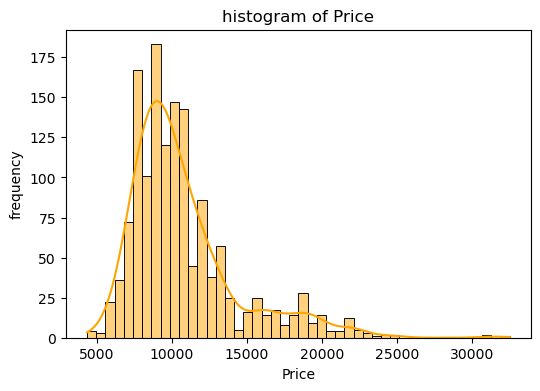

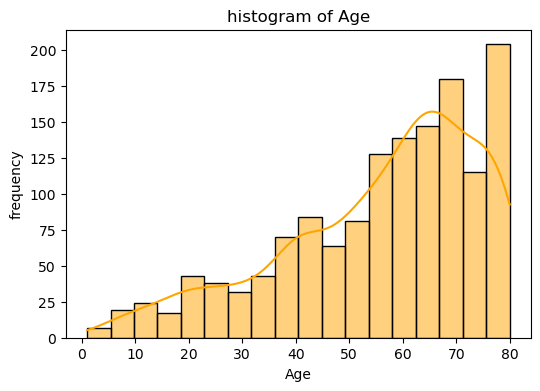

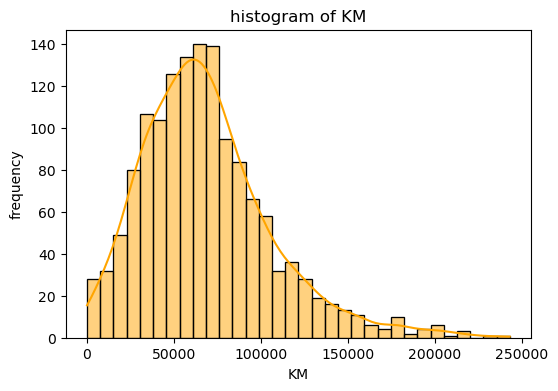

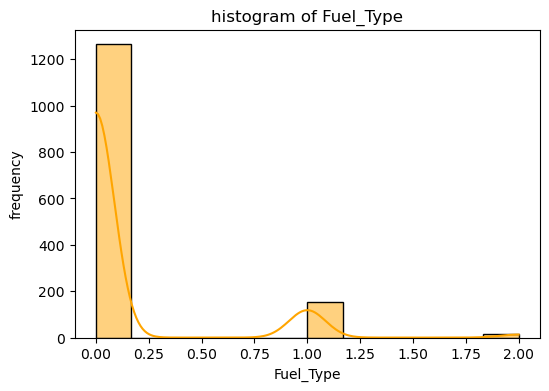

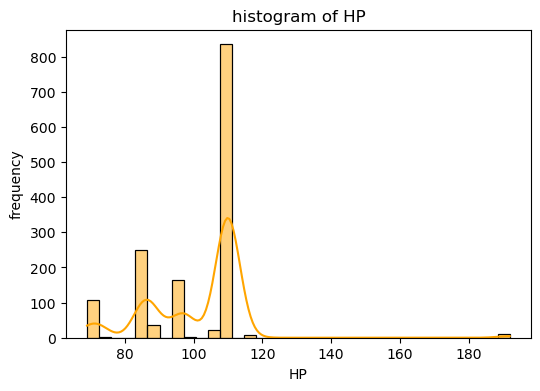

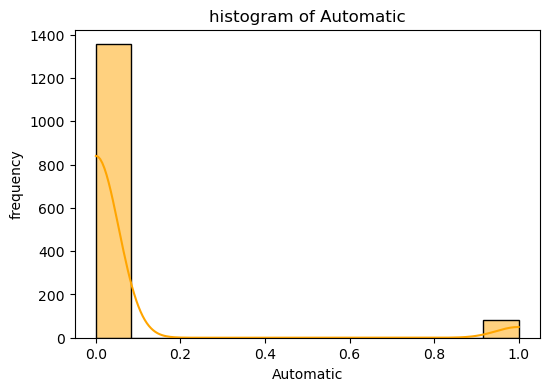

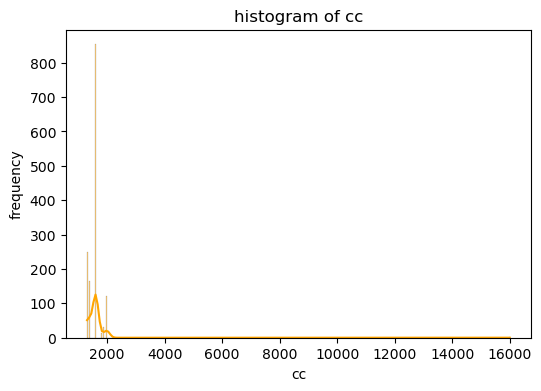

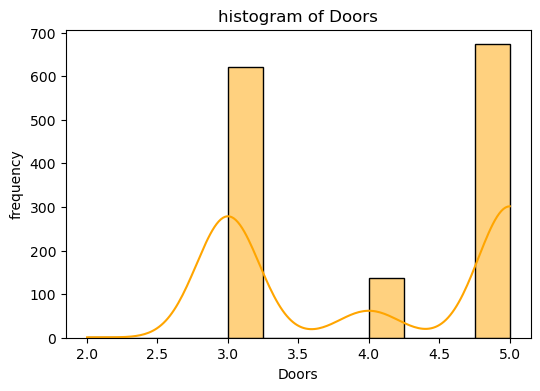

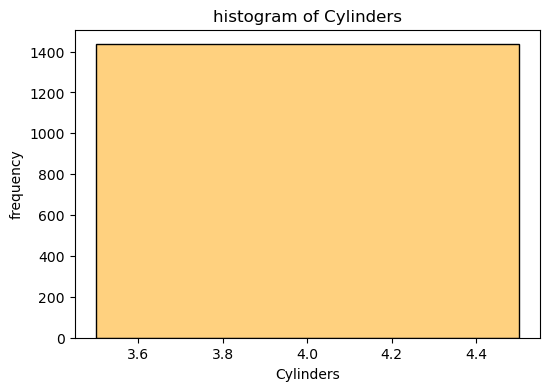

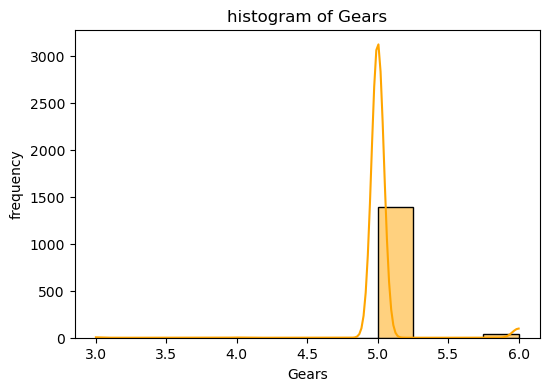

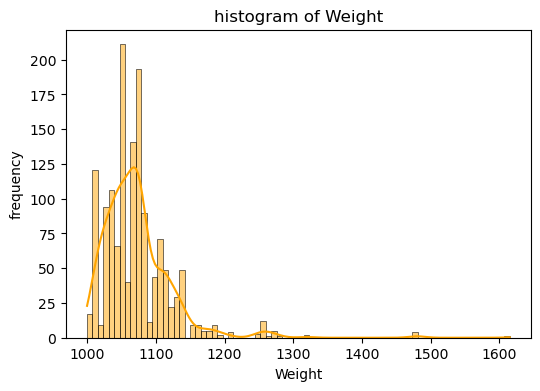

In [18]:
#creating histogram
for col in data.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,color='orange',edgecolor='black')
    plt.title(f'histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

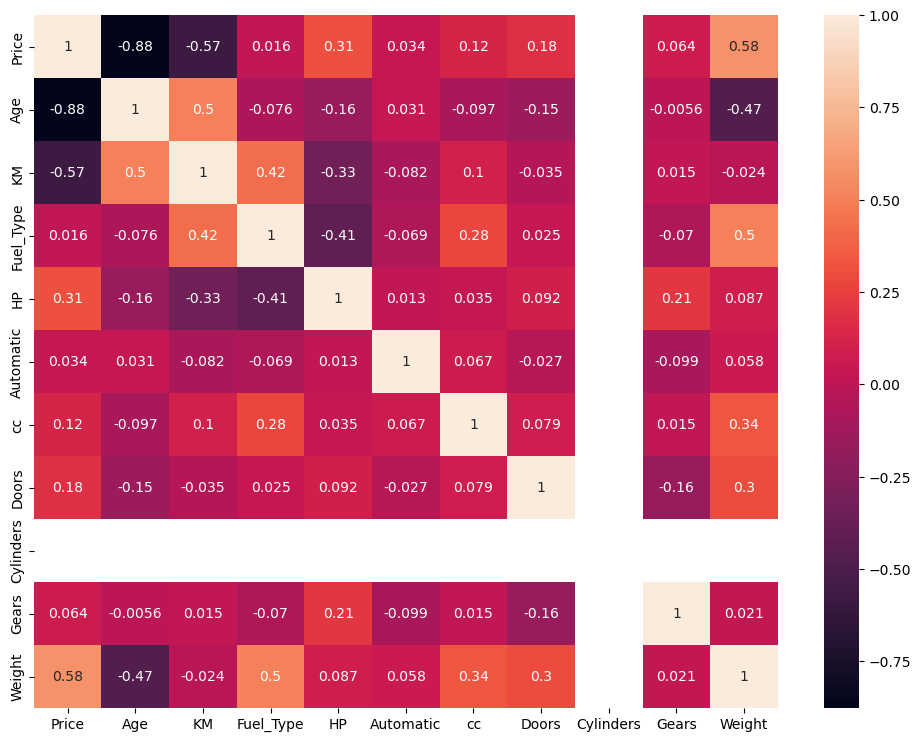

In [19]:
#correlation heatmap

plt.figure(figsize=(12,9))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

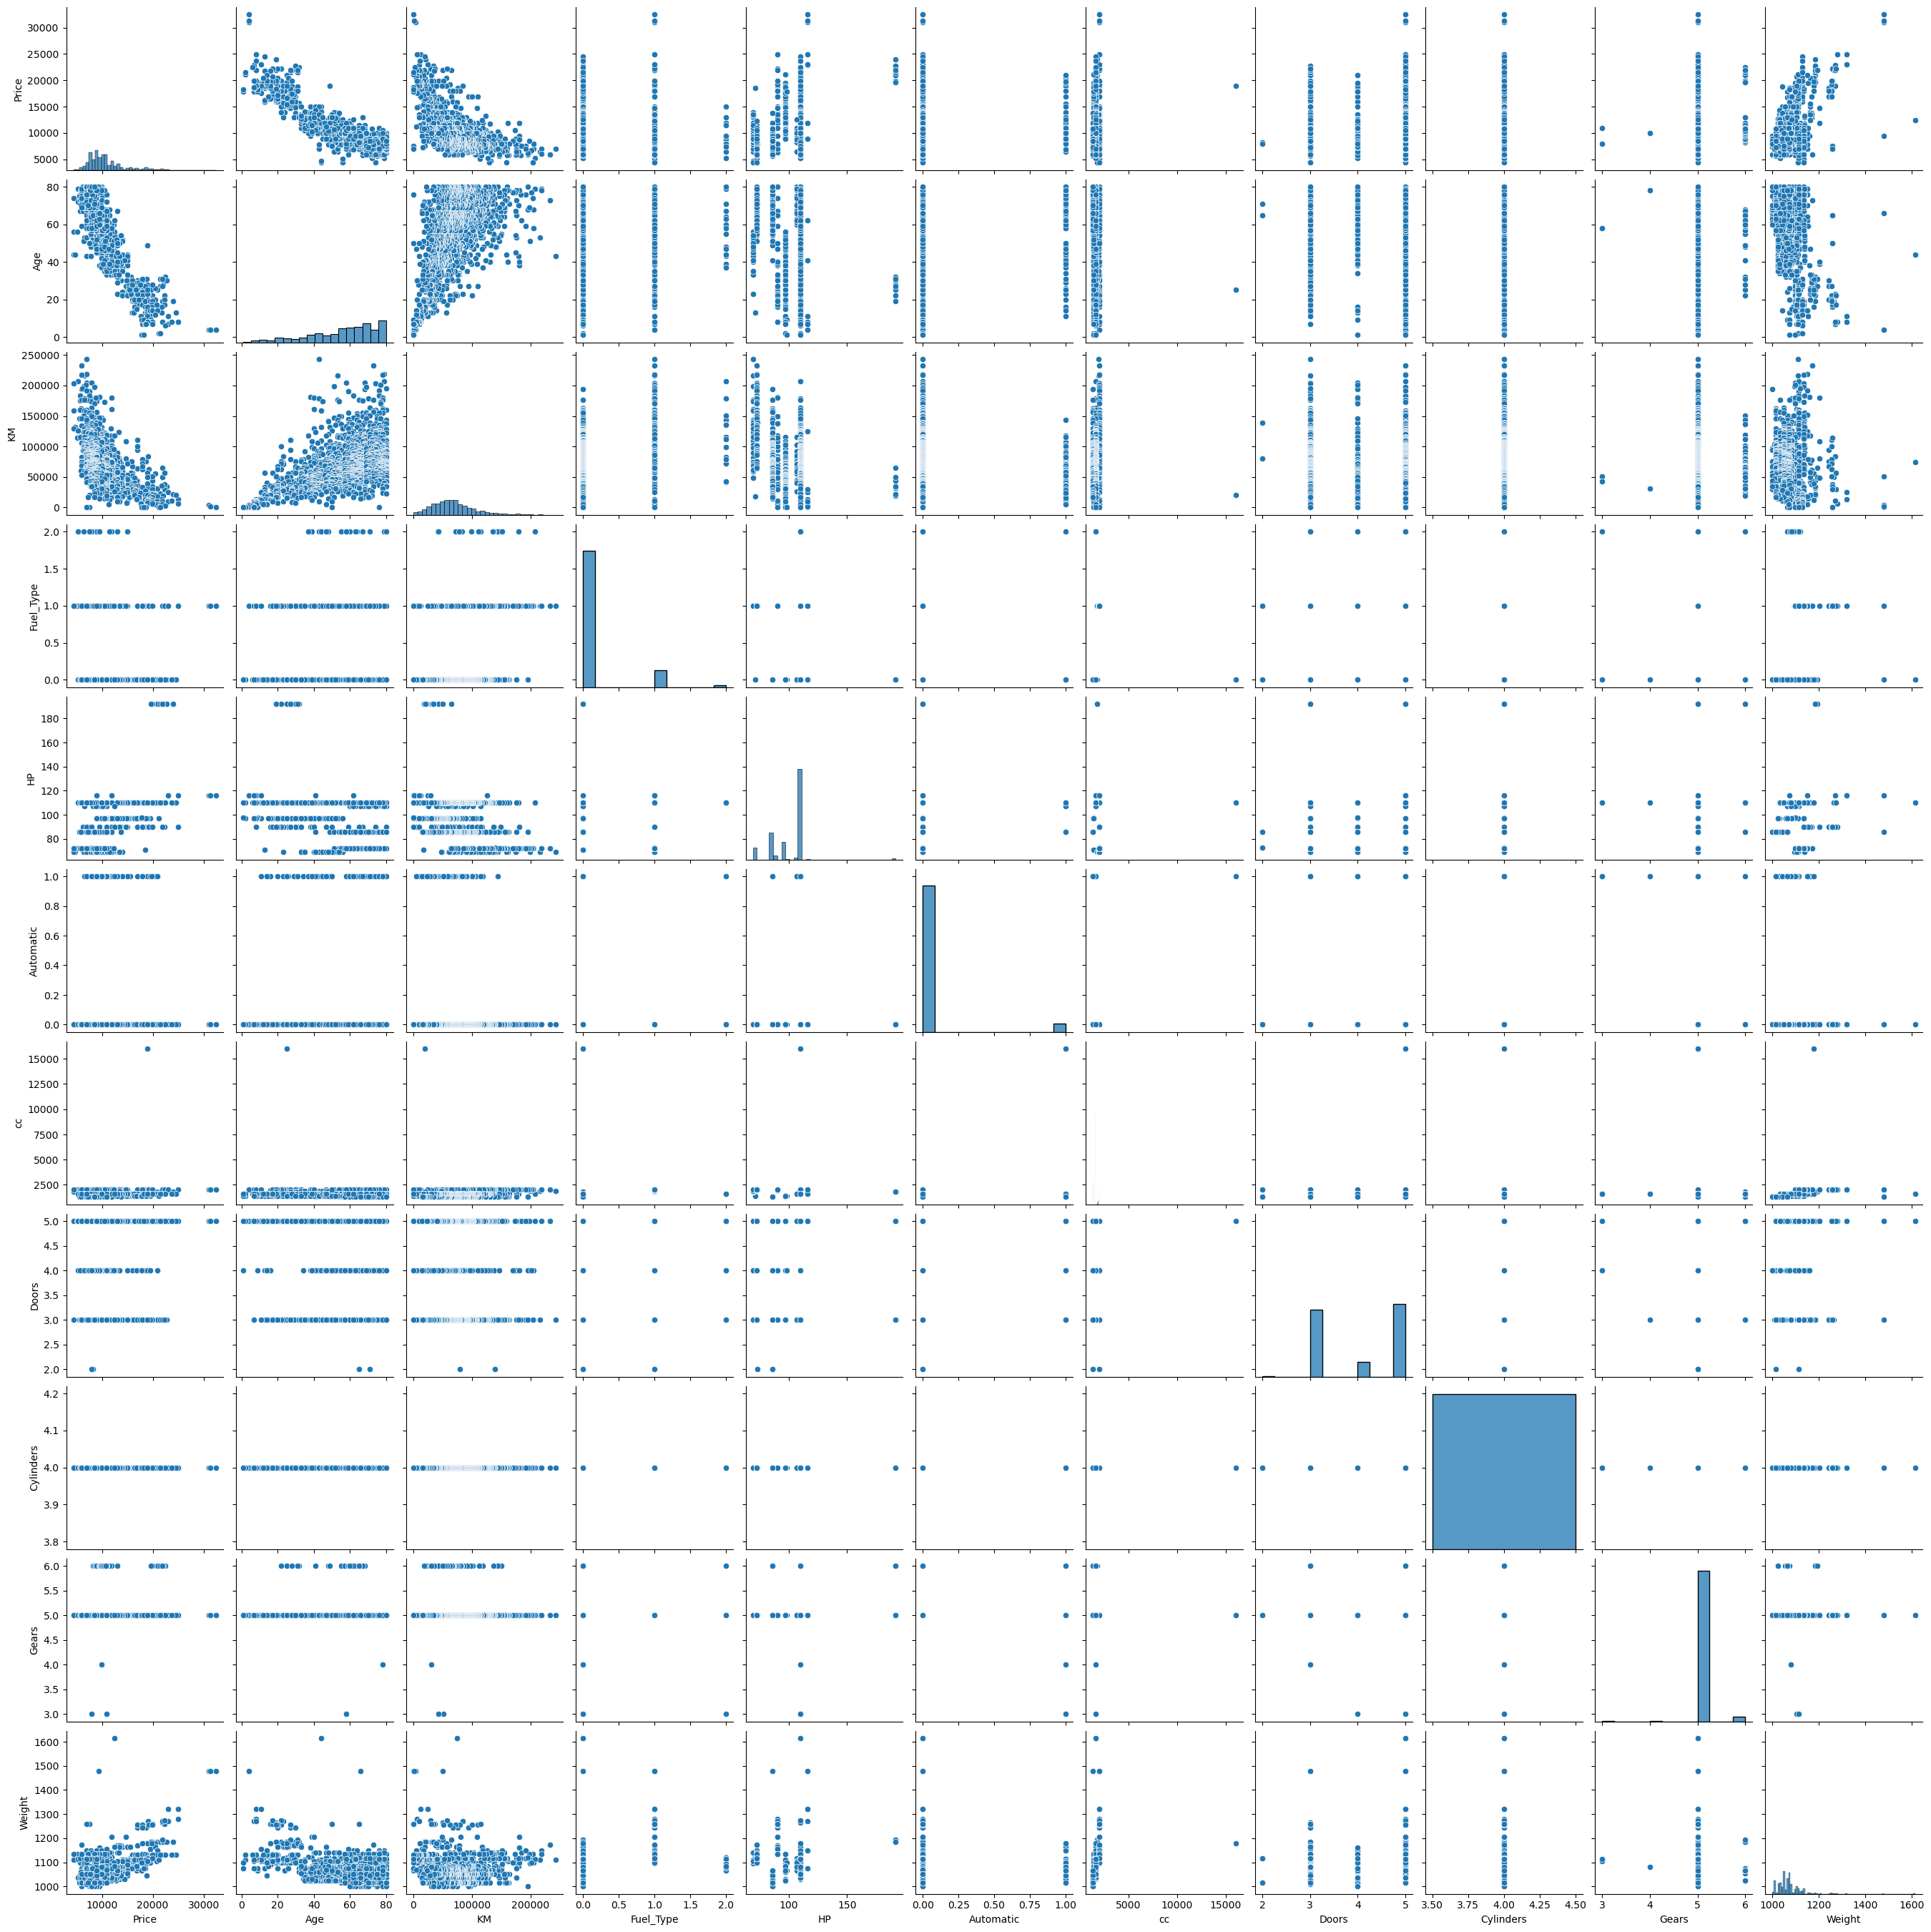

In [20]:
sns.pairplot(data)
plt.show()

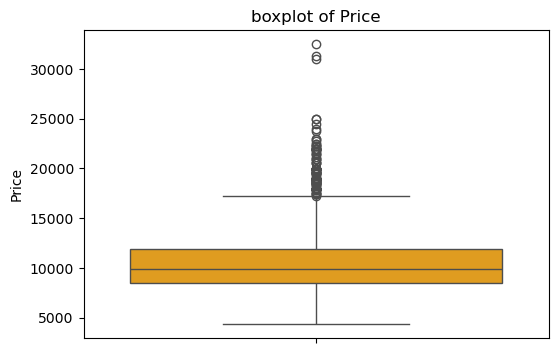

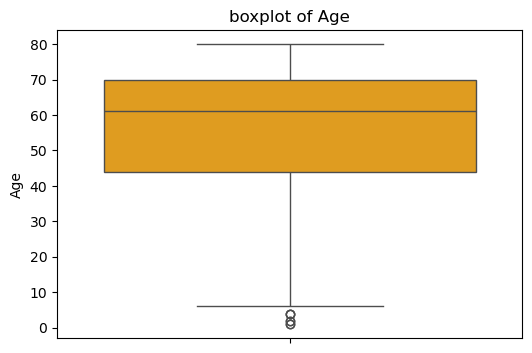

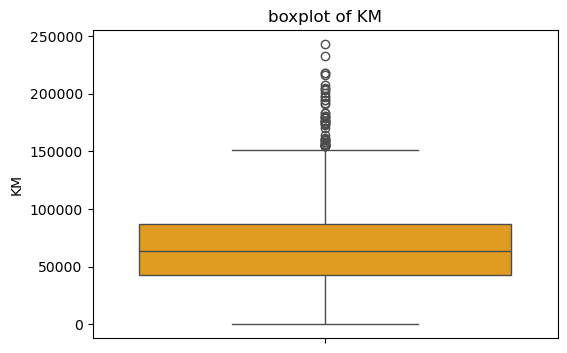

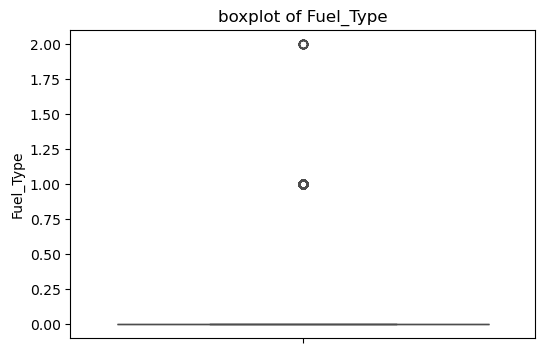

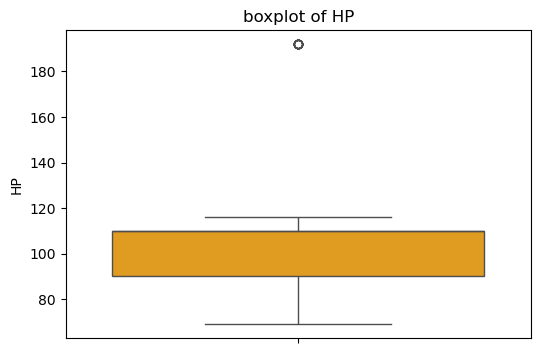

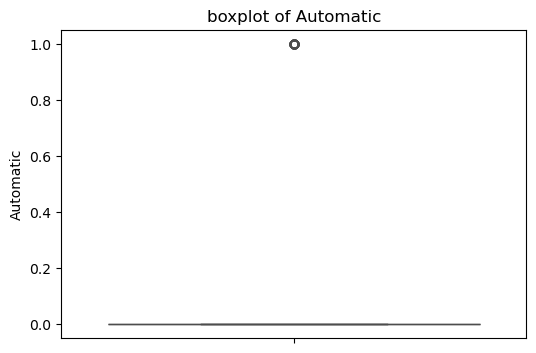

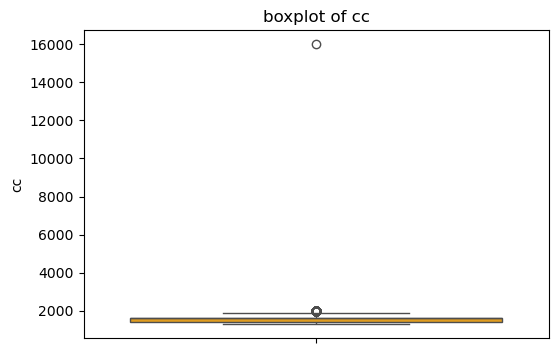

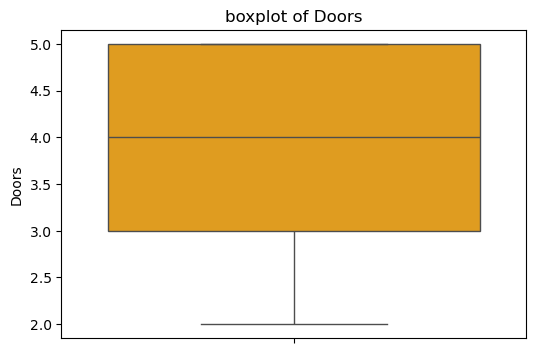

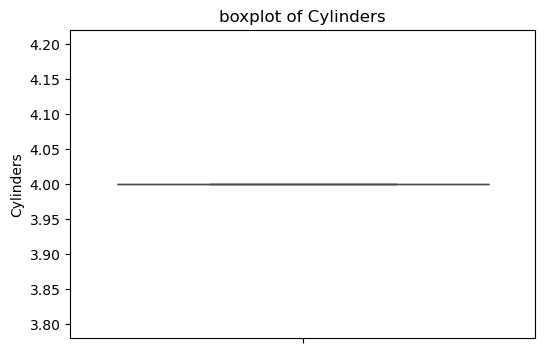

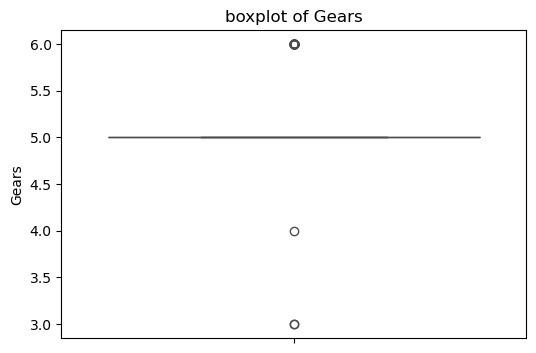

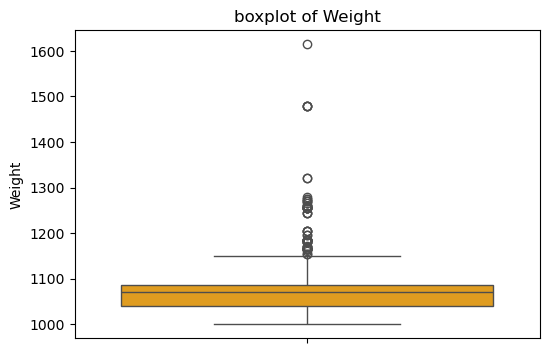

In [21]:
#Create boxplots for to identify outliers.

for col in data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data[col],color='orange')
    plt.title(f'boxplot of {col}')
    plt.show()

In [22]:
# remove cylinder column because it is constant
data = data.drop('Cylinders',axis=1)
data

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,5,1165
1,13750,23,72937,1,90,0,2000,3,5,1165
2,13950,24,41711,1,90,0,2000,3,5,1165
3,14950,26,48000,1,90,0,2000,3,5,1165
4,13750,30,38500,1,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,0,86,0,1300,3,5,1025
1431,10845,72,19000,0,86,0,1300,3,5,1015
1432,8500,71,17016,0,86,0,1300,3,5,1015
1433,7250,70,16916,0,86,0,1300,3,5,1015


### Split the dataset into training and testing sets

In [23]:
X = data.iloc[:,1:]
y = data['Price']

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape,y_train.shape)

(1148, 9) (287, 9) (1148,) (1148,)


### Build a multiple linear regression model using the training dataset

In [26]:
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error

In [27]:
#model 1

X1 = X_train[['Age','KM','HP']]
X1_test = X_test[['Age','KM','HP']]

model1 = LinearRegression()
model1.fit(X1,y_train)

y_pred1 = model1.predict(X1_test)

print('model 1 R2:',r2_score(y_test,y_pred1))
print('model 1 coefficients:',model1.coef_)

model 1 R2: 0.8027722166637183
model 1 coefficients: [-1.57716407e+02 -1.05670865e-02  3.90665529e+01]


In [28]:
#model 2

X2 = X_train[['Age','KM','HP','Weight','cc']]
X2_test = X_test[['Age','KM','HP','Weight','cc']]

model2 = LinearRegression()
model2.fit(X2,y_train)

y_pred2 = model2.predict(X2_test)

print('model 2 R2:',r2_score(y_test,y_pred2))
print('model 2 coefficients:',model2.coef_)

model 2 R2: 0.6844972572988204
model 2 coefficients: [-1.24869289e+02 -1.63457041e-02  3.39870190e+01  2.13300740e+01
 -1.49303144e+00]


In [29]:
#model 3

X3 = X_train
X3_test = X_test

model3 = LinearRegression()
model3.fit(X3,y_train)

y_pred3 = model3.predict(X3_test)

print('model 3 R2:',r2_score(y_test,y_pred3))
print('model 3 coefficients:',model3.coef_)

model 3 R2: 0.7459355566579875
model 3 coefficients: [-1.25737454e+02 -1.62683072e-02 -2.07462751e+02  2.95848381e+01
  4.86310809e+02 -1.18897837e+00 -3.16978780e+01  7.66525790e+02
  2.13446441e+01]


In [30]:
import statsmodels.api as sm

In [31]:
X_sm = sm.add_constant(X3) # add intercept
ols_model = sm.OLS(y_train,X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     826.6
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:52:51   Log-Likelihood:                -9901.7
No. Observations:                1148   AIC:                         1.982e+04
Df Residuals:                    1138   BIC:                         1.987e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8895.2344   1518.503     -5.858      0.0

### Evaluate the model

In [33]:
def evaluate_model(y_true,y_pred,model_name):
    mse = mean_squared_error(y_true,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true,y_pred)

    print(f'performance of {model_name}:')
    print('MSE:',mse)
    print('RMSE:',rmse)
    print('R2:',r2)

In [34]:
#model 1
y_pred1 = model1.predict(X1_test)
evaluate_model(y_test,y_pred1,'Model 1')

performance of Model 1:
MSE: 2028605.2097629318
RMSE: 1424.2911253542695
R2: 0.8027722166637183


In [35]:
#model 2
y_pred2 = model2.predict(X2_test)
evaluate_model(y_test,y_pred2,'Model 2')

performance of Model 2:
MSE: 3245133.6049689725
RMSE: 1801.4254369717812
R2: 0.6844972572988204


In [36]:
#model 3
y_pred3 = model3.predict(X3_test)
evaluate_model(y_test,y_pred3,'Model 3')

performance of Model 3:
MSE: 2613204.106747747
RMSE: 1616.54078412756
R2: 0.7459355566579875


### Lasso and Ridge methods on the model

In [38]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [39]:
# Lasso

#model 1

lasso1 = Lasso(alpha=1.0)
lasso1.fit(X1,y_train)

y_pred1_lasso = lasso1.predict(X1_test)
evaluate_model(y_test,y_pred1_lasso,'Lasso Regression on Model 1')

performance of Lasso Regression on Model 1:
MSE: 2028543.835930062
RMSE: 1424.2695797952233
R2: 0.80277818363302


In [41]:
#model 2

lasso2 = Lasso(alpha=1.0)
lasso2.fit(X2,y_train)

y_pred2_lasso = lasso2.predict(X2_test)
evaluate_model(y_test,y_pred2_lasso,'Lasso Regression on Model 2')

performance of Lasso Regression on Model 2:
MSE: 3244456.627102852
RMSE: 1801.2375265641265
R2: 0.6845630753511747


In [42]:
#model 3

lasso3 = Lasso(alpha=1.0)
lasso3.fit(X3,y_train)

y_pred3_lasso = lasso3.predict(X3_test)
evaluate_model(y_test,y_pred3_lasso,'Lasso Regression on Model 3')

performance of Lasso Regression on Model 3:
MSE: 2652176.9438528717
RMSE: 1628.5505653349765
R2: 0.7421464870866498


In [43]:
# Ridge (Handle Multicollinearity)

# model 1

ridge1 = Ridge(alpha=1.0)
ridge1.fit(X1,y_train)

y_pred1_ridge = ridge1.predict(X1_test)
evaluate_model(y_test,y_pred1_ridge,'Ridge Regression on Model 1')


performance of Ridge Regression on Model 1:
MSE: 2028599.4775035488
RMSE: 1424.289113032726
R2: 0.8027727739731476


In [44]:
# model 2

ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2,y_train)

y_pred2_ridge = ridge2.predict(X2_test)
evaluate_model(y_test,y_pred2_ridge,'Ridge Regression on Model 2')

performance of Ridge Regression on Model 2:
MSE: 3245118.816407004
RMSE: 1801.421332283762
R2: 0.6844986950922765


In [45]:
# model 3

ridge3 = Ridge(alpha=1.0)
ridge3.fit(X3,y_train)

y_pred3_ridge = ridge3.predict(X3_test)
evaluate_model(y_test,y_pred3_ridge,'Ridge Regression on Model 3')

performance of Ridge Regression on Model 3:
MSE: 2622624.7848081226
RMSE: 1619.4520013906317
R2: 0.7450196468286965


## Interview Questions:

### 1.What is Normalization & Standardization and how is it helpful?
     Normalization scales data to a fixed range 0 to 1.
     Standardization rescales data so it has a mean of 0 and standard deviation of 1
     Both help models train faster and perform better by ensuring all features contribute equally

### 2.What techniques can be used to address multicollinearity in multiple linear regression?
    Multicollinearity can be handled by removing or combining correlated features to reduce redundancy
    It can also be addressed using regularization techinques like lasso and ridge regression